Install Python Libraries

In [1]:
pip install pandas matplotlib mysql-connector-python openai

Note: you may need to restart the kernel to use updated packages.


Python: Connect MySQL Database

In [2]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="travel_agent_db"
)

query = "SELECT * FROM bookings"

df = pd.read_sql(query, conn)

print(df)

   booking_id customer_name destination travel_date booking_channel    price
0           1         Rahul         Goa  2025-01-15         Website  12000.0
1           2          Amit       Delhi  2025-02-10      Mobile App   8000.0
2           3          Sara         Goa  2025-03-20         Website  15000.0
3           4          Neha      Jaipur  2025-03-25           Agent   9000.0
4           5          Ravi         Goa  2025-04-05      Mobile App  14000.0
5           6         Anita      Mumbai  2025-04-10         Website  11000.0


C:\Users\panka\AppData\Local\Temp\ipykernel_45956\4137096716.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Data Cleaning & Preparation

In [3]:
df["travel_date"] = pd.to_datetime(df["travel_date"])
df["month"] = df["travel_date"].dt.month
df["year"] = df["travel_date"].dt.year

Data Analysis Using Pandas

In [4]:
destination_counts = df["destination"].value_counts()

print(destination_counts)

destination
Goa       3
Delhi     1
Jaipur    1
Mumbai    1
Name: count, dtype: int64


In [5]:
avg_price = df["price"].mean()

print("Average Travel Cost:", avg_price)

Average Travel Cost: 11500.0


In [6]:
channel_counts = df["booking_channel"].value_counts()

print(channel_counts)

booking_channel
Website       3
Mobile App    2
Agent         1
Name: count, dtype: int64


Visualization

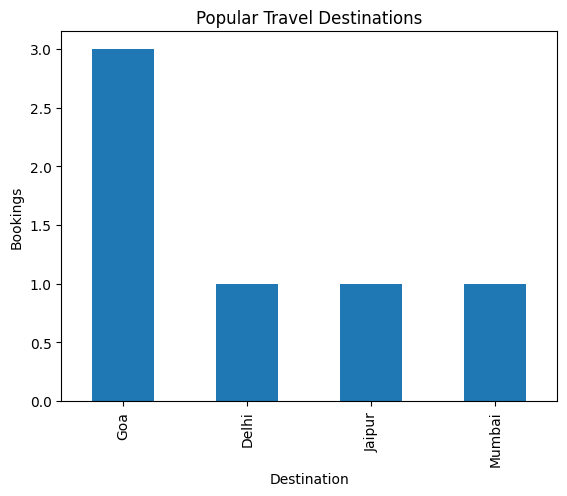

In [7]:
import matplotlib.pyplot as plt

destination_counts.plot(kind="bar")

plt.title("Popular Travel Destinations")
plt.xlabel("Destination")
plt.ylabel("Bookings")

plt.show()

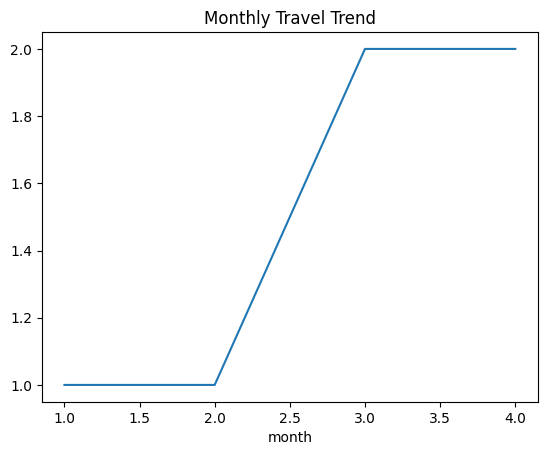

In [8]:
monthly_trend = df.groupby("month").size()

monthly_trend.plot(kind="line")

plt.title("Monthly Travel Trend")

plt.show()

AI Travel Insights using OpenAI

In [9]:
from openai import OpenAI

client = OpenAI()

summary = df.describe().to_string()

response = client.responses.create(
    model="gpt-4.1-mini",
    input=f"Analyze this travel booking dataset and provide insights:\n{summary}"
)

print(response.output_text)

Here is an analysis of the travel booking dataset based on the provided summary statistics:

### Dataset Overview
- **Number of bookings:** 6
- **Year:** All bookings are for the year 2025.
- **Travel dates:** Range from January 15, 2025 to April 10, 2025.
- **Price:** Ranges from 8,000 to 15,000 currency units.
- **Month:** Corresponds to the travel dates, spanning from January (1) to April (4).

---

### Key Insights

1. **Booking Period:**
   - The travel bookings cover the first four months of 2025 (January to April).
   - The earliest travel date is January 15, 2025.
   - The latest travel date is April 10, 2025.

2. **Price Analysis:**
   - **Mean price:** 11,500 units.
   - **Minimum price:** 8,000 units.
   - **Maximum price:** 15,000 units.
   - **Price distribution:** Prices increase across bookings, with the 25th percentile at 9,500 and the 75th percentile at 13,500.
   - The standard deviation of prices is about 2,739, indicating moderate variability in booking prices.

3. 